In [1]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt

import darling
import disell

In [2]:
base = Path(
    "/dtu/3d-imaging-center/projects/2022_QIM_PMP/analysis/Adam/"
    "111_june/111_cells_2_6-2pct_mosalayers_2x"
)

out = base / "disell_output"
out.mkdir(exist_ok=True)

In [3]:
def get_layer_number(path):
    return int(re.search(r"layer_(\d+)_", path.name).group(1))


layer_dirs = sorted(
    [p for p in base.iterdir() if p.is_dir() and p.name.startswith("layer_")],
    key=get_layer_number,
)

volume = np.stack([np.load(p / "mean.npy") for p in layer_dirs], axis=0)

print("layers:", [p.name for p in layer_dirs])
print("volume:", volume.shape)

layers: ['layer_1_1', 'layer_2_1', 'layer_3_1', 'layer_4_1', 'layer_5_1', 'layer_6_1', 'layer_7_1', 'layer_8_1', 'layer_9_1', 'layer_10_1', 'layer_11_1']
volume: (11, 200, 500, 2)


(np.float64(-0.5), np.float64(499.5), np.float64(199.5), np.float64(-0.5))

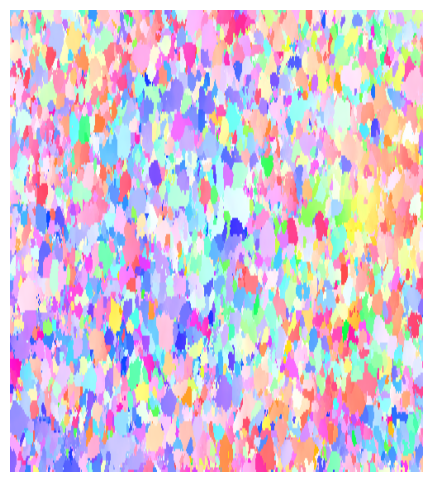

In [4]:
phi = np.linspace(np.nanmin(volume[..., 0]), np.nanmax(volume[..., 0]), 64)
chi = np.linspace(np.nanmin(volume[..., -1]), np.nanmax(volume[..., -1]), 64)
coord = np.meshgrid(phi, chi, indexing="ij")

rgb_volume = []

for z in range(volume.shape[0]):
    rgb, _, _ = darling.transforms.rgb(
        volume[z],
        norm="full",
        coordinates=coord,
    )
    rgb_volume.append(rgb)

rgb_volume = np.stack(rgb_volume, axis=0)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_volume[z], aspect=2.8)
plt.axis("off")


In [5]:
transforms = disell.register(
    volume,
    registration_channel=0,
    verbose=True,
)

registered = disell.apply_transforms(
    volume,
    transforms,
    pad_value=np.nan,
)

print("registered:", registered.shape)

[0] Shift: [ 4. -1.]
[1] Shift: [3. 0.]
[2] Shift: [2. 0.]
[3] Shift: [1. 0.]
[4] Shift: [1. 0.]
[6] Shift: [0. 0.]
[7] Shift: [-1.  0.]
[8] Shift: [-2.  0.]
[9] Shift: [-3.  0.]
[10] Shift: [-4.  0.]
registered: (11, 200, 500, 2)


In [6]:
mask = np.all(np.isfinite(registered), axis=-1)

seg_input = registered.copy()

for c in range(seg_input.shape[-1]):
    vals = seg_input[..., c][mask]
    lo, hi = np.nanpercentile(vals, [1, 99])
    seg_input[..., c] = (seg_input[..., c] - lo) / (hi - lo)

seg_input[~np.isfinite(seg_input)] = 0

In [7]:
footprint = np.zeros((3, 3, 3), dtype=bool)

# in-plane neighbours
footprint[1, :, :] = True

# direct layer-to-layer neighbours
footprint[0, 1, 1] = True
footprint[2, 1, 1] = True

In [8]:
result = disell.flood_fill_dfxm(
    seg_input,
    footprint=footprint,
    local_threshold=0.02,
    footprint_tolerance=0.85,
    mask=mask,
    max_iterations=1_500_000,
    min_grain_size=20,
    recycle_small_grains=True,
    stagnation_tolerance=10_000,
)

labels = result["segmentation"]

print("labels:", labels.shape)
print("number of cells:", labels.max())

labels: (11, 200, 500)
number of cells: 1894


In [9]:
segmented_mask = labels > 0

segmented_fraction = np.count_nonzero(segmented_mask) / segmented_mask.size

print(f"Segmented fraction: {segmented_fraction:.3f}")
print(f"Segmented percentage: {100 * segmented_fraction:.1f}%")

Segmented fraction: 0.396
Segmented percentage: 39.6%


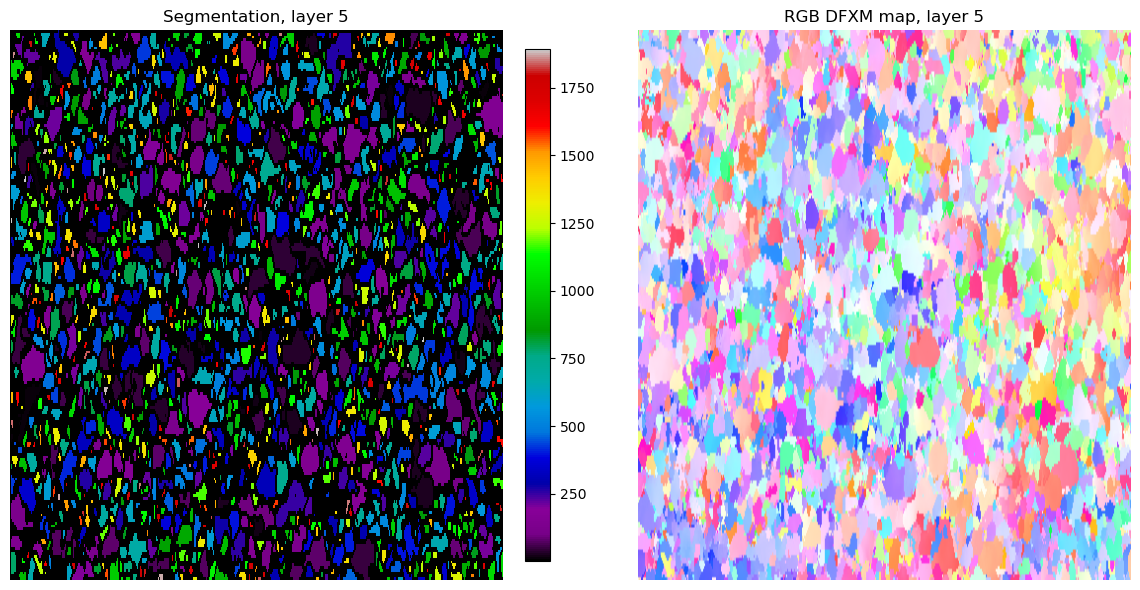

In [10]:
import matplotlib as mpl
z = labels.shape[0] // 2

# Choose zoom region in (y, x)
y0, y1 = 0, -1
x0, x1 = 0, -1

labels_crop = labels[z, y0:y1, x0:x1]
rgb_crop = rgb_volume[z, y0:y1, x0:x1]

# Copy colormap and set label 0 to black
cmap = mpl.colormaps["nipy_spectral"].copy()
cmap.set_under("black")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im0 = axes[0].imshow(
    labels_crop,
    cmap=cmap,
    interpolation="nearest",
    aspect=2.8,
    vmin=0.5,   # values below this, i.e. label 0, use set_under colour
)
axes[0].set_title(f"Segmentation, layer {z}")
axes[0].axis("off")

axes[1].imshow(rgb_crop, aspect=2.8)
axes[1].set_title(f"RGB DFXM map, layer {z}")
axes[1].axis("off")

fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

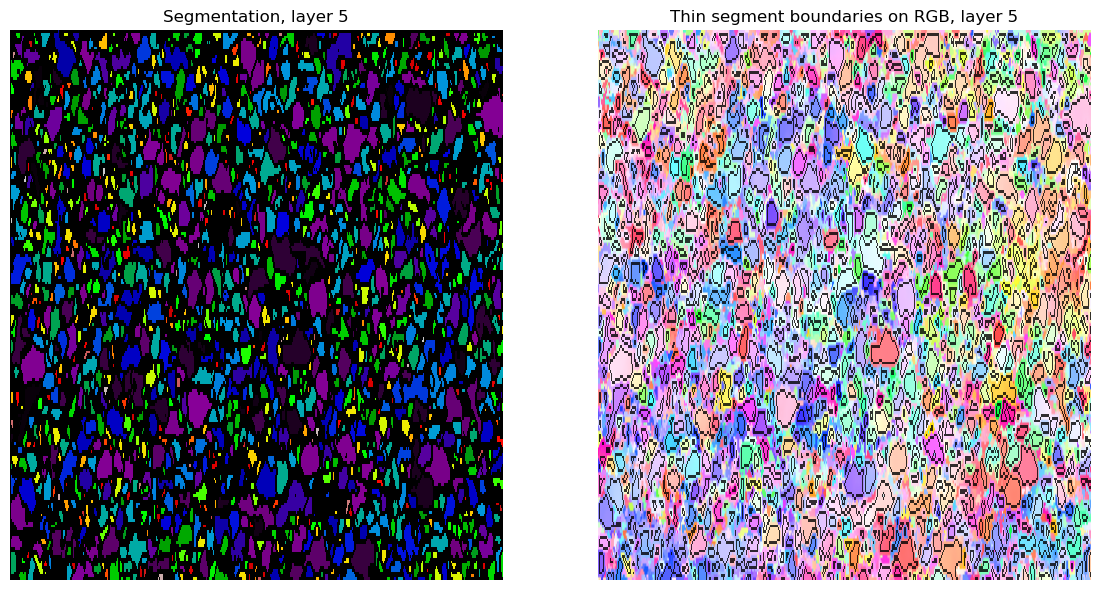

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries

z = labels.shape[0] // 2

y0, y1 = 0, -1
x0, x1 = 0, -1

labels_crop = labels[z, y0:y1, x0:x1]
rgb_crop = rgb_volume[z, y0:y1, x0:x1]

# Thin 1-pixel boundaries
boundaries = find_boundaries(
    labels_crop,
    mode="inner",
    background=0,
)

# Only keep boundaries inside segmented regions
boundaries = boundaries & (labels_crop > 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(labels_crop, cmap="nipy_spectral", interpolation="nearest", aspect=2.8)
axes[0].set_title(f"Segmentation, layer {z}")
axes[0].axis("off")

axes[1].imshow(rgb_crop, aspect=2.8)

boundary_overlay = np.zeros((*boundaries.shape, 4))
boundary_overlay[boundaries] = [0, 0, 0, 0.8]  # black, slightly transparent

axes[1].imshow(boundary_overlay, interpolation="nearest", aspect=2.8)
axes[1].set_title(f"Thin segment boundaries on RGB, layer {z}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Number of segmented cells in layer 5: 1489
Median cell area: 13.0 pixels
Mean cell area: 27.6 pixels


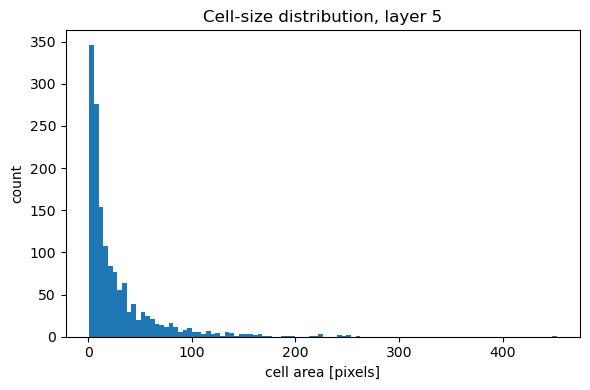

In [12]:
z = labels.shape[0] // 2

labels_z = labels[z]

# Count pixels per label
label_ids, counts = np.unique(labels_z, return_counts=True)

# Remove background label 0
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_px = counts[valid]

print(f"Number of segmented cells in layer {z}: {len(cell_sizes_px)}")
print(f"Median cell area: {np.median(cell_sizes_px):.1f} pixels")
print(f"Mean cell area: {np.mean(cell_sizes_px):.1f} pixels")

plt.figure(figsize=(6, 4))
plt.hist(cell_sizes_px, bins=100)
plt.xlabel("cell area [pixels]")
plt.ylabel("count")
plt.title(f"Cell-size distribution, layer {z}")
plt.tight_layout()
plt.show()

Number of segmented 3D cells: 1894
Min cell volume: 21 voxels
Median cell volume: 95.0 voxels
Mean cell volume: 230.1 voxels
Max cell volume: 4464 voxels


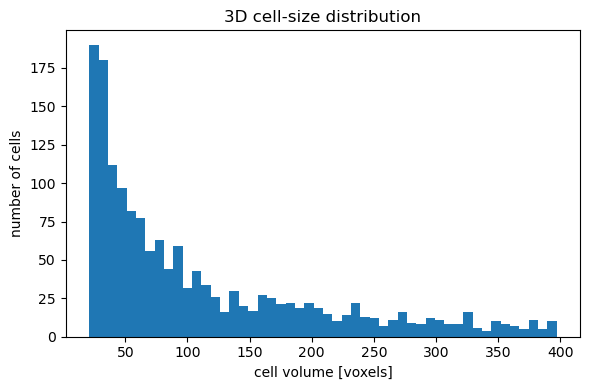

In [13]:
label_ids, counts = np.unique(labels, return_counts=True)

# Remove background / unsegmented label
valid = label_ids > 0
label_ids = label_ids[valid]
cell_sizes_vox = counts[valid]

print(f"Number of segmented 3D cells: {len(cell_sizes_vox)}")
print(f"Min cell volume: {cell_sizes_vox.min()} voxels")
print(f"Median cell volume: {np.median(cell_sizes_vox):.1f} voxels")
print(f"Mean cell volume: {np.mean(cell_sizes_vox):.1f} voxels")
print(f"Max cell volume: {cell_sizes_vox.max()} voxels")

upper = np.percentile(cell_sizes_vox, 90)

plt.figure(figsize=(6, 4))
plt.hist(cell_sizes_vox[cell_sizes_vox <= 400], bins=50)
plt.xlabel("cell volume [voxels]")
plt.ylabel("number of cells")
plt.title("3D cell-size distribution")
plt.tight_layout()
plt.show()

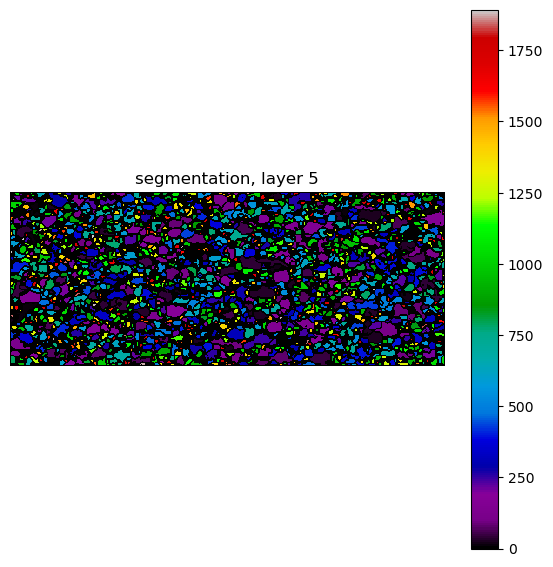

In [14]:
z = labels.shape[0] // 2

plt.figure(figsize=(7, 7))
plt.imshow(labels[z], cmap="nipy_spectral", interpolation="nearest")
plt.title(f"segmentation, layer {z}")
plt.axis("off")
plt.colorbar()

In [15]:
from scipy import ndimage as ndi

# Use the same connectivity logic as your segmentation footprint
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True
structure[0, 1, 1] = True
structure[2, 1, 1] = True

labels_cc = np.zeros_like(labels, dtype=np.int32)

new_label = 1
min_component_size = 50

for old_label in np.unique(labels):
    if old_label == 0:
        continue

    old_mask = labels == old_label
    cc, n_cc = ndi.label(old_mask, structure=structure)

    for component_id in range(1, n_cc + 1):
        component = cc == component_id
        size = component.sum()

        if size < min_component_size:
            continue

        labels_cc[component] = new_label
        new_label += 1

print("old max label:", labels.max())
print("new max label:", labels_cc.max())

old max label: 1894
new max label: 1338


In [16]:
labels = labels_cc

In [17]:
import pyvista as pv

In [18]:
phi = np.linspace(np.nanmin(registered[..., 0]), np.nanmax(registered[..., 0]), 64)
chi = np.linspace(np.nanmin(registered[..., -1]), np.nanmax(registered[..., -1]), 64)
coord = np.meshgrid(phi, chi, indexing="ij")

rgb_volume = []

for z in range(registered.shape[0]):
    rgb, colorkey, colorgrid = darling.transforms.rgb(
        registered[z],
        norm="full",
        coordinates=coord,
    )
    rgb_volume.append(rgb)

rgb_volume = np.stack(rgb_volume, axis=0)

print("rgb_volume:", rgb_volume.shape)
print("labels:", labels.shape)

rgb_volume: (11, 200, 500, 3)
labels: (11, 200, 500)


In [19]:
ids, counts = np.unique(labels, return_counts=True)

# Remove background
keep = ids != 0
ids = ids[keep]
counts = counts[keep]

order = np.argsort(counts)[::-1]

for i in range(min(20, len(ids))):
    print(f"label {ids[order[i]]}: {counts[order[i]]} voxels")

label 36: 4464 voxels
label 22: 2677 voxels
label 156: 2599 voxels
label 256: 2565 voxels
label 241: 2496 voxels
label 32: 2450 voxels
label 144: 2391 voxels
label 151: 2330 voxels
label 26: 2248 voxels
label 104: 2228 voxels
label 184: 2186 voxels
label 105: 2091 voxels
label 48: 2040 voxels
label 273: 1989 voxels
label 127: 1959 voxels
label 85: 1891 voxels
label 88: 1887 voxels
label 623: 1851 voxels
label 301: 1798 voxels
label 8: 1736 voxels


In [20]:
cell_id = ids[order[0]]
print("chosen cell:", cell_id)

chosen cell: 36


In [21]:
cell_mask = labels == cell_id

zz, yy, xx = np.nonzero(cell_mask)

points = np.column_stack([xx, yy, zz]).astype(float)
colors = rgb_volume[cell_mask]

print("points:", points.shape)
print("colors:", colors.shape)

points: (4464, 3)
colors: (4464, 3)


2026-06-08 17:37:31.536 (  26.819s) [    7F680CF3B740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/pbs.672159.hnode41/ipykernel_418673/95477042.py:14: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


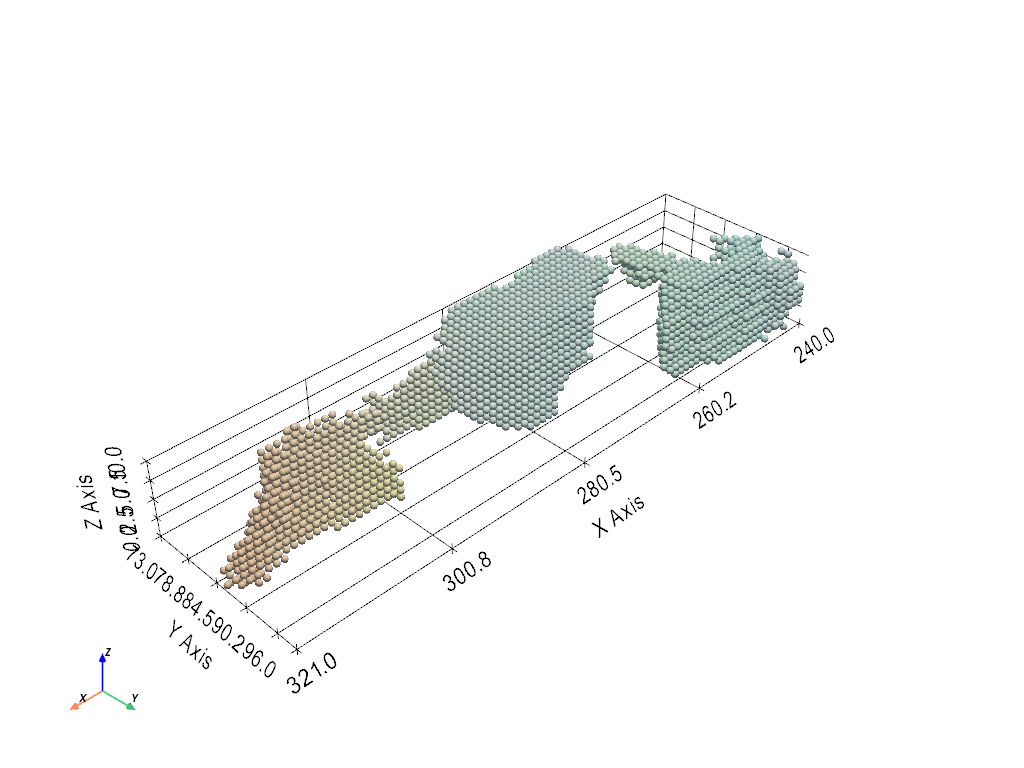

In [22]:
cloud = pv.PolyData(points)
cloud["RGB"] = (np.clip(colors, 0, 1) * 255).astype(np.uint8)

plotter = pv.Plotter()
plotter.add_points(
    cloud,
    scalars="RGB",
    rgb=True,
    point_size=8,
    render_points_as_spheres=True,
)
plotter.add_axes()
plotter.show_grid()
plotter.show()

cell_id = 36
number of voxels in this cell = 4464
valid voxels = 4464
phi range: 0.2489 to 0.8282
chi range: 7.8644 to 8.1669


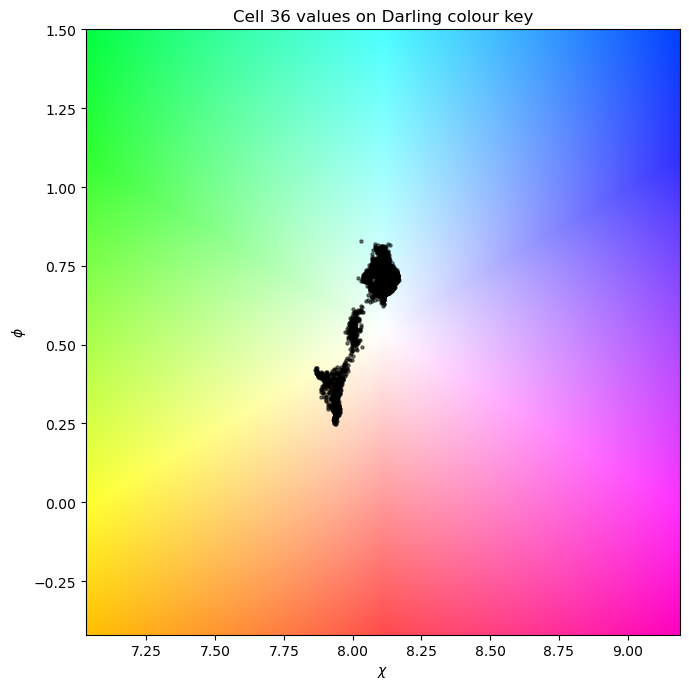

In [23]:
cell_id = cell_id  # the cell you want

# Extract only this cell
mask = labels == cell_id
zz, yy, xx = np.nonzero(mask)

print(f"cell_id = {cell_id}")
print(f"number of voxels in this cell = {len(xx)}")

if len(xx) == 0:
    raise ValueError(f"No voxels found for cell_id={cell_id}. Check that this label exists.")

# Extract only this cell's values
cell_values = registered[zz, yy, xx]

cell_phi = cell_values[..., 0]
cell_chi = cell_values[..., -1]

valid = ~np.isnan(cell_phi) & ~np.isnan(cell_chi)

print(f"valid voxels = {np.count_nonzero(valid)}")
print(f"phi range: {np.nanmin(cell_phi):.4f} to {np.nanmax(cell_phi):.4f}")
print(f"chi range: {np.nanmin(cell_chi):.4f} to {np.nanmax(cell_chi):.4f}")

fig, ax = plt.subplots(figsize=(7, 7))

# Show Darling colour key
ax.imshow(
    colorkey,
    origin="lower",
    extent=[
        np.nanmin(chi),
        np.nanmax(chi),
        np.nanmin(phi),
        np.nanmax(phi),
    ],
    aspect="auto",
)

# Overlay only selected cell values
ax.scatter(
    cell_chi[valid],
    cell_phi[valid],
    s=5,
    c="black",
    alpha=0.5,
)

ax.set_xlabel(r"$\chi$")
ax.set_ylabel(r"$\phi$")
ax.set_title(f"Cell {cell_id} values on Darling colour key")

plt.tight_layout()
plt.show()

In [24]:
from scipy import ndimage as ndi
import numpy as np

cell_id = int(ids[order[0]])
cell_mask = labels == cell_id

# Same connectivity idea as your segmentation footprint
structure = np.zeros((3, 3, 3), dtype=bool)
structure[1, :, :] = True
structure[0, 1, 1] = True
structure[2, 1, 1] = True

cc, n_cc = ndi.label(cell_mask, structure=structure)

print("cell_id:", cell_id)
print("number of disconnected components:", n_cc)

component_sizes = np.bincount(cc.ravel())[1:]
print("component sizes:", component_sizes)

cell_id: 36
number of disconnected components: 1
component sizes: [4464]


In [25]:
out = base / "disell_3d_output"
out.mkdir(exist_ok=True)

np.save(out / "labels_cc.npy", labels_cc)
np.save(out / "rgb_volume.npy", rgb_volume)

print("saved arrays to:", out)

saved arrays to: /dtu/3d-imaging-center/projects/2022_QIM_PMP/analysis/Adam/111_june/111_cells_2_6-2pct_mosalayers_2x/disell_3d_output


In [26]:
labels_to_export = labels_cc

# Export only segmented voxels
mask_export = labels_to_export > 0

zz, yy, xx = np.nonzero(mask_export)

# Physical spacing. Replace these with real values if you know them.
dx = 1.0
dy = 1.0
dz = 1.0

points = np.column_stack([
    xx * dx,
    yy * dy,
    zz * dz,
]).astype(np.float32)

colors = rgb_volume[mask_export]
colors_uint8 = (np.clip(colors, 0, 1) * 255).astype(np.uint8)

label_values = labels_to_export[mask_export].astype(np.int32)

cloud = pv.PolyData(points)
cloud["RGB"] = colors_uint8
cloud["label"] = label_values

vtp_path = out / "segmentation_rgb_pointcloud.vtp"
cloud.save(vtp_path)

print("saved:", vtp_path)
print("points:", points.shape[0])

saved: /dtu/3d-imaging-center/projects/2022_QIM_PMP/analysis/Adam/111_june/111_cells_2_6-2pct_mosalayers_2x/disell_3d_output/segmentation_rgb_pointcloud.vtp
points: 417447


/tmp/pbs.672159.hnode41/ipykernel_418673/2684211306.py:11: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  plotter.show()


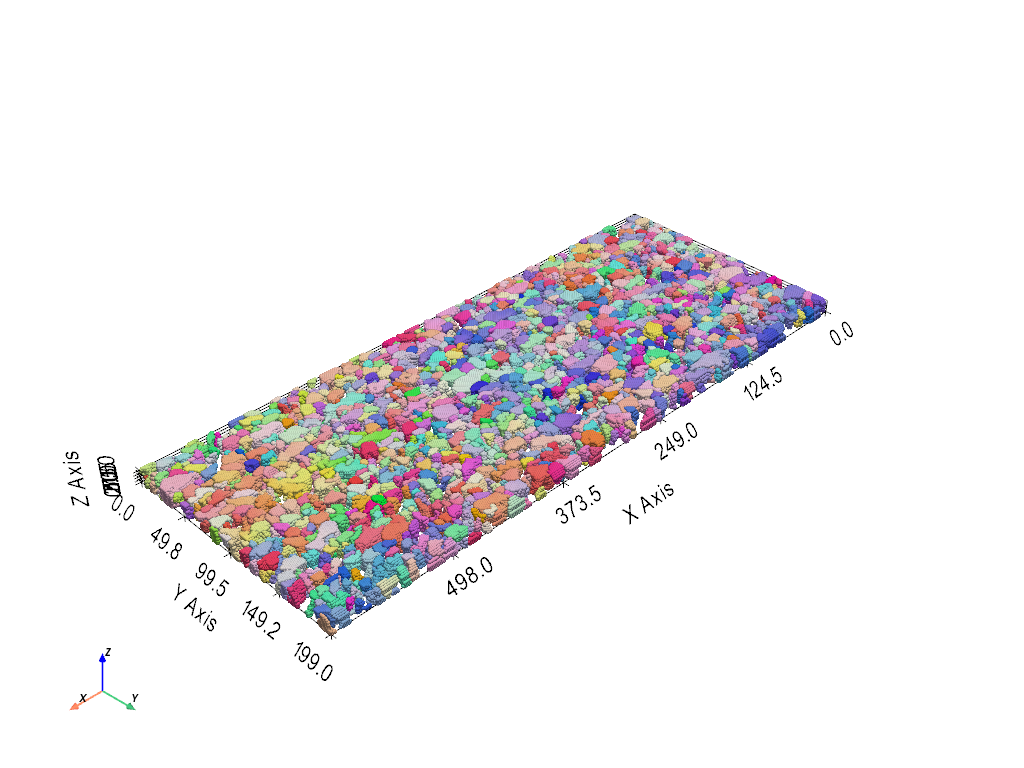

In [27]:
plotter = pv.Plotter()
plotter.add_points(
    cloud,
    scalars="RGB",
    rgb=True,
    point_size=4,
    render_points_as_spheres=True,
)
plotter.add_axes()
plotter.show_grid()
plotter.show()